# Read image and perform image operations

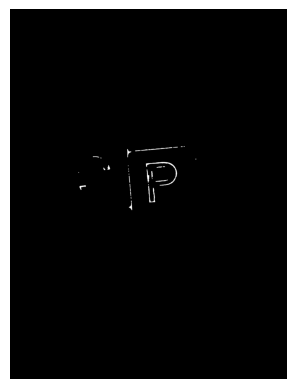

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Read in image
image = cv2.imread('images/SP.jpg')
# image = cv2.rotate(image,cv2.ROTATE_90_COUNTERCLOCKWISE)

gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
median = cv2.medianBlur(gray,5)
gaussian = cv2.GaussianBlur(median,(5,5),1)

sharpen_kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
sharp = cv2.filter2D(gaussian, -1, sharpen_kernel)

closeKernel = cv2.getStructuringElement(cv2.MORPH_RECT, (4,4))
openKernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

#Adaptive threshold to find high value areas
thresh = cv2.adaptiveThreshold(sharp, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV,181,65)
close = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, closeKernel, iterations=2)
open = cv2.morphologyEx(close, cv2.MORPH_OPEN, openKernel, iterations=3)


plt.axis('off')
plt.imshow(open, cmap ='gray')
plt.show()


## Get Contours

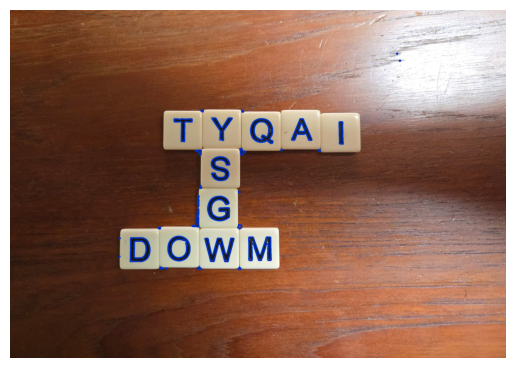

Contour count: 37


,Aspect Ratio,Contour Area,Bounding Area,Solidity
count,37.00,37.00,37.00,37.00
mean,0.94,3999.34,7151.32,0.85
std,0.33,5648.54,9534.74,0.19
min,0.18,36.00,49.00,0.44
25%,0.79,105.00,135.00,0.76
50%,0.90,499.50,702.00,0.94
75%,1.12,7823.00,17582.00,0.99
max,1.59,18411.50,29260.00,1.00


In [ ]:
from PeelBackClasses.ContourHelper import Contour
import pandas as pd
#Use threshold to inform contour lines and draw contours on image
contours, hierarchy= cv2.findContours(open, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
forshow = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
cv2.drawContours(forshow, contours,-1,(0,50,200),7)

contourObjs = [Contour(x) for x in contours]

def getStats(contoursList: list[Contour])-> pd.DataFrame:
    labels = ['Aspect Ratio','Contour Area','Bounding Area','Solidity']
    stats = pd.DataFrame([ [x.getAspectRatio(),x.getContourArea(),x.getBoundingArea(), x.getSolidity()] for x in contoursList], columns=labels)
    return stats
    

plt.imshow(forshow, cmap='gray')
plt.axis('off')
plt.show()
print(f'Contour count: {len(contours)}')
getStats(contourObjs).describe().round(2)

## Filter Contours that are too small or too long

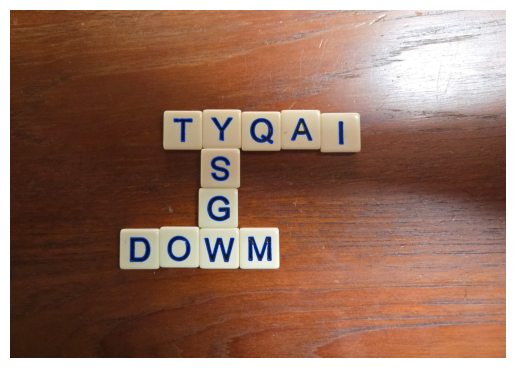

Contour count: 14


,Aspect Ratio,Contour Area,Bounding Area,Solidity
count,14.00,14.00,14.00,14.00
mean,0.83,10079.68,18040.00,0.74
std,0.22,4905.31,6733.93,0.25
min,0.18,3173.50,3942.00,0.44
25%,0.80,7749.50,13742.75,0.49
50%,0.87,9221.75,18988.50,0.81
75%,0.90,10823.62,22699.50,0.97
max,1.23,18411.50,29260.00,0.99


In [ ]:
from PeelBackClasses.ContourHelper import Contour 
import pandas as pd


#Create empty trimmed list 
firstTrim = []

#Define parameters that will filter out nominal contours
#Parameters should be very broad to account for any camera position
areamin = 2000
minratio = 0.15
maxratio = 1.3

for cnt in contourObjs:
    if cnt is None or len(cnt.getContour()) == 0: continue

    area = cnt.getContourArea()
    ratio = cnt.getWidth()/cnt.getHeight()
    solidity = cnt.getSolidity()

    if (area > areamin) and (ratio> minratio and ratio < maxratio) :
        firstTrim.append(cnt)

contTemp = [x.getContour() for x in firstTrim]

forshow = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
cv2.drawContours(forshow, contTemp,-1,(0,50,200),5)

plt.imshow(forshow)
plt.axis('off')
plt.show()
print(f'Contour count: {len(firstTrim)}')
getStats(firstTrim).describe().round(2)

## Show Each Image

C:\Users\isaac\AppData\Local\Temp\ipykernel_36456\3780410445.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


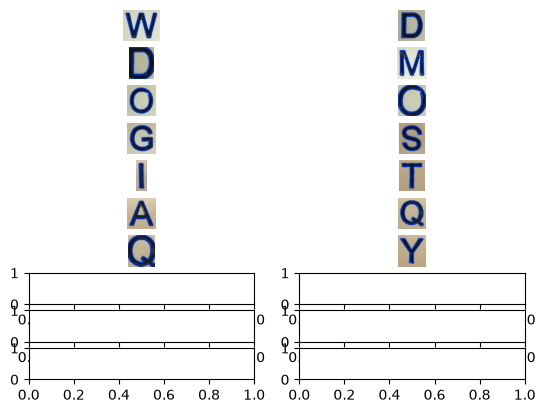

In [ ]:
import numpy as np

#Show each contour
fig, axs = plt.subplots(10,(len(firstTrim)//10)+1)
clips =[]
axesUnrav = np.ravel(axs)
for index in range(len(firstTrim)):
    ax = axesUnrav[index]
    cnt :Contour = firstTrim[index]
    ax.axis('off')
    padding = 20
    newCropped = cnt.getCroppedContourFromImage(forshow,padding)
    clips.append(newCropped)
    ax.imshow(newCropped)


fig.show()

